# Lyapunov Exponent Relationship Under the α-Transform

**Question:** How do Lyapunov exponents of the regular map $f$ and the α-transformed map $g_\alpha = \alpha f + (1-\alpha)x$ relate?

**Why it matters:** If Lyapunov exponents are invariant under constant α, then the α-transform preserves the information-theoretic structure of the dynamics (via Pesin's theorem: $h_{KS} = \max(0, \Lambda)$). This would make the transform an exact conjugacy, not just a stability modification.

**Background:** [inverse_correspondence §4](inverse_correspondence.ipynb) sets up this computation but the cells haven't been executed. The [cross-theory connections §1](cross_theory_connections.md) notes that if the group structure $\Gamma_\alpha \Gamma_\beta = \Gamma_{\alpha\beta}$ implies Lyapunov invariance, this is the natural framework. [alpha_transform §10.2](alpha_transform.ipynb) flags this as an open question.

**Theory:** The instantaneous expansion rate is $|g'(x)| = |1 + \alpha(f'(x) - 1)|$. The Lyapunov exponent is:
$$\Lambda_\alpha = \langle \ln |g'_\alpha(x)| \rangle = \left\langle \ln |1 + \alpha(f'(x) - 1)| \right\rangle$$

For $\alpha = 1$: $\Lambda_1 = \langle \ln |f'(x)| \rangle$ (standard). For general α, the logarithm prevents simple factoring. So invariance is **not** guaranteed by algebra alone — it depends on the *distribution* of $f'$ along orbits.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from petrification.maps import logistic
from petrification.transforms import alpha_transform
from petrification.iteration import iterate, iterate_transformed
from petrification.bifurcation import compute_bifurcation, compute_bifurcation_transformed

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12})

# Load precomputed results
_cache = np.load('cache/lyapunov_results.npz')


## §2. Lyapunov Exponent Computation

Compute $\Lambda = \frac{1}{N} \sum_{n=0}^{N-1} \ln|g'(x_n)|$ along orbits of both the regular and α-transformed logistic map.

In [2]:
def lyapunov(f, a, x0, n_iter=10000, n_discard=1000, alpha=None):
    if alpha is not None:
        traj = iterate_transformed(logistic, alpha, a, x0, n_iter)
    else:
        traj = iterate(logistic, a, x0, n_iter)
    traj = traj[n_discard:]
    f_prime = a * (1 - 2 * traj[:-1])
    if alpha is not None:
        g_prime = 1 + alpha * (f_prime - 1)
    else:
        g_prime = f_prime
    gp_abs = np.maximum(np.abs(g_prime), 1e-30)
    return np.mean(np.log(gp_abs))


## §3. Experiment 1: Regular vs Inverted — Direct Comparison

Compare $\Lambda_{\alpha=1}$ and $\Lambda_{\alpha=-1}$ across the full logistic parameter range $a \in [2.5, 4]$.

**Prediction:** If the group structure forces invariance, $\Lambda_{-1} = \Lambda_1$ everywhere. If not, they'll differ — especially in chaotic regions where the orbit distribution matters most.

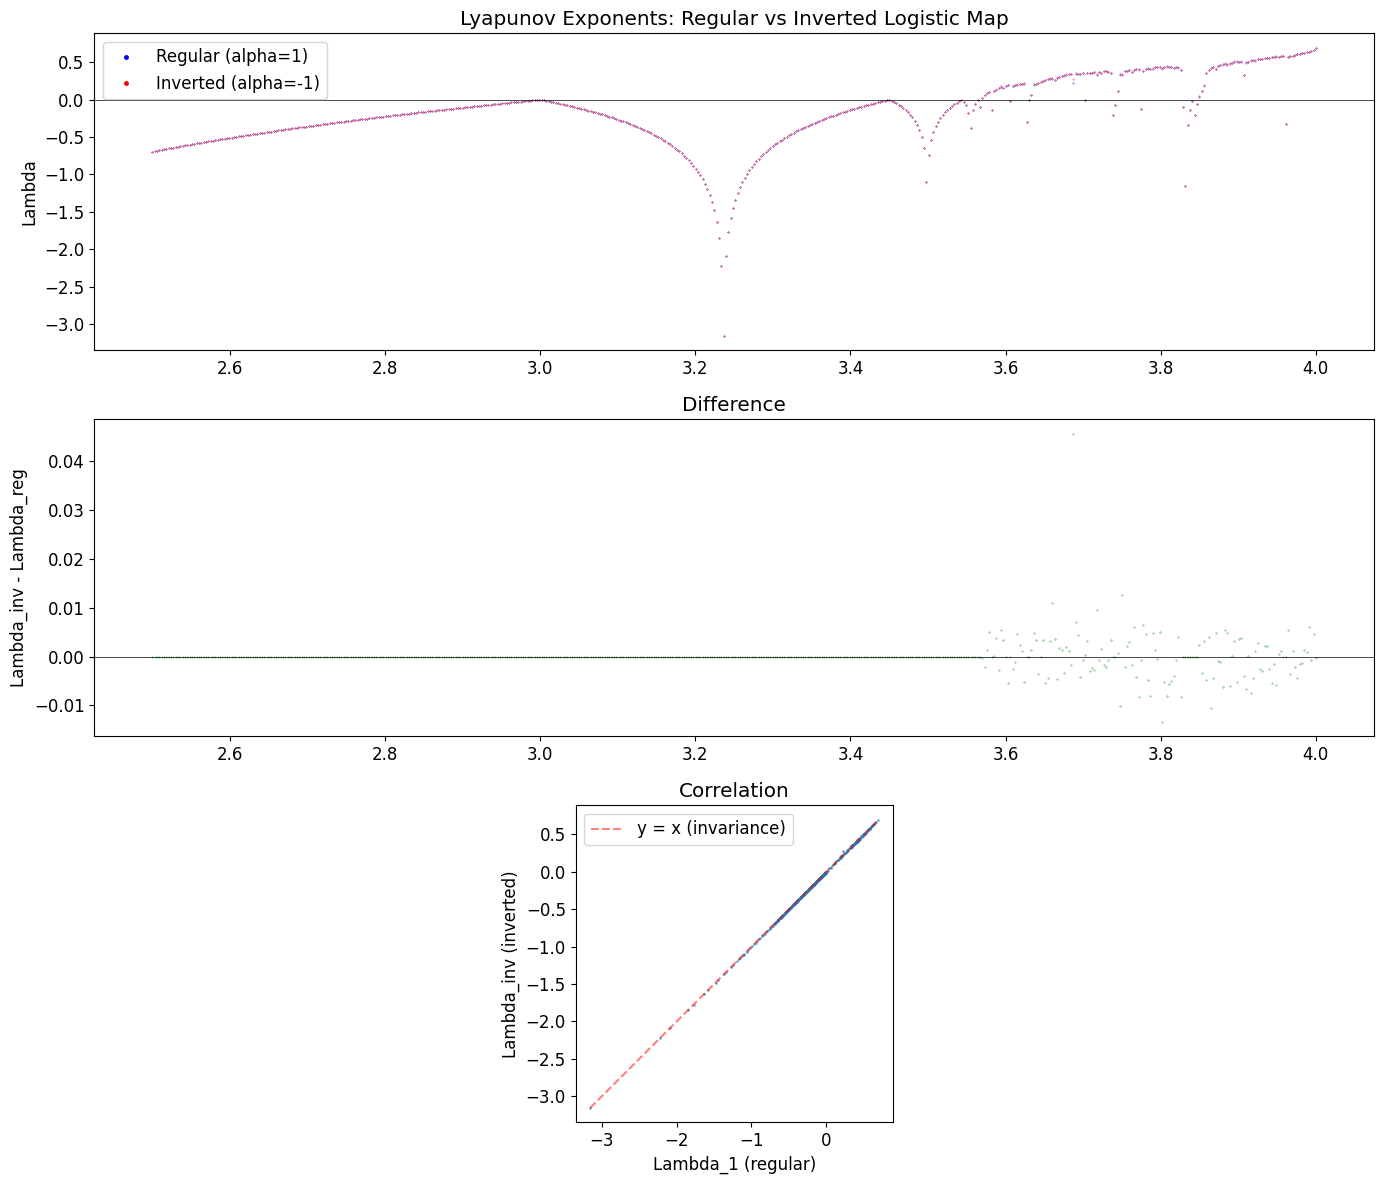

Pearson r = 0.999979
RMSE of difference = 0.003047
Max |difference| = 0.045661


In [3]:
# Load precomputed Lyapunov scans
a_values = _cache['a_values']
lyap_regular = _cache['lyap_regular']
lyap_inverted = _cache['lyap_inverted']

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Panel 1: Both Lyapunov exponents
axes[0].plot(a_values, lyap_regular, 'b.', markersize=0.5, label='Regular (alpha=1)')
axes[0].plot(a_values, lyap_inverted, 'r.', markersize=0.5, label='Inverted (alpha=-1)')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set(ylabel='Lambda', title='Lyapunov Exponents: Regular vs Inverted Logistic Map')
axes[0].legend(markerscale=10)

# Panel 2: Difference
lyap_diff = lyap_inverted - lyap_regular
axes[1].plot(a_values, lyap_diff, 'g.', markersize=0.5)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set(ylabel='Lambda_inv - Lambda_reg', title='Difference')

# Panel 3: Correlation scatter
mask = np.isfinite(lyap_regular) & np.isfinite(lyap_inverted)
axes[2].scatter(lyap_regular[mask], lyap_inverted[mask], s=1, alpha=0.5)
lims = [min(lyap_regular[mask].min(), lyap_inverted[mask].min()),
        max(lyap_regular[mask].max(), lyap_inverted[mask].max())]
axes[2].plot(lims, lims, 'r--', alpha=0.5, label='y = x (invariance)')
axes[2].set(xlabel='Lambda_1 (regular)', ylabel='Lambda_inv (inverted)', title='Correlation')
axes[2].set_aspect('equal')
axes[2].legend()

plt.tight_layout()
plt.show()

# Statistics
r = np.corrcoef(lyap_regular[mask], lyap_inverted[mask])[0, 1]
rmse = np.sqrt(np.mean(lyap_diff[mask]**2))
print(f'Pearson r = {r:.6f}')
print(f'RMSE of difference = {rmse:.6f}')
print(f'Max |difference| = {np.max(np.abs(lyap_diff[mask])):.6f}')


## §4. Experiment 2: Continuous α Sweep

How does $\Lambda_\alpha$ vary as α goes from −2 to +2 at several characteristic parameter values?

**Key a values:**
- $a = 3.2$: period-2 cycle (mildly interesting)
- $a = 3.57$: onset of chaos
- $a = 3.83$: period-3 window  
- $a = 4.0$: fully chaotic ($\Lambda_1 = \ln 2$)

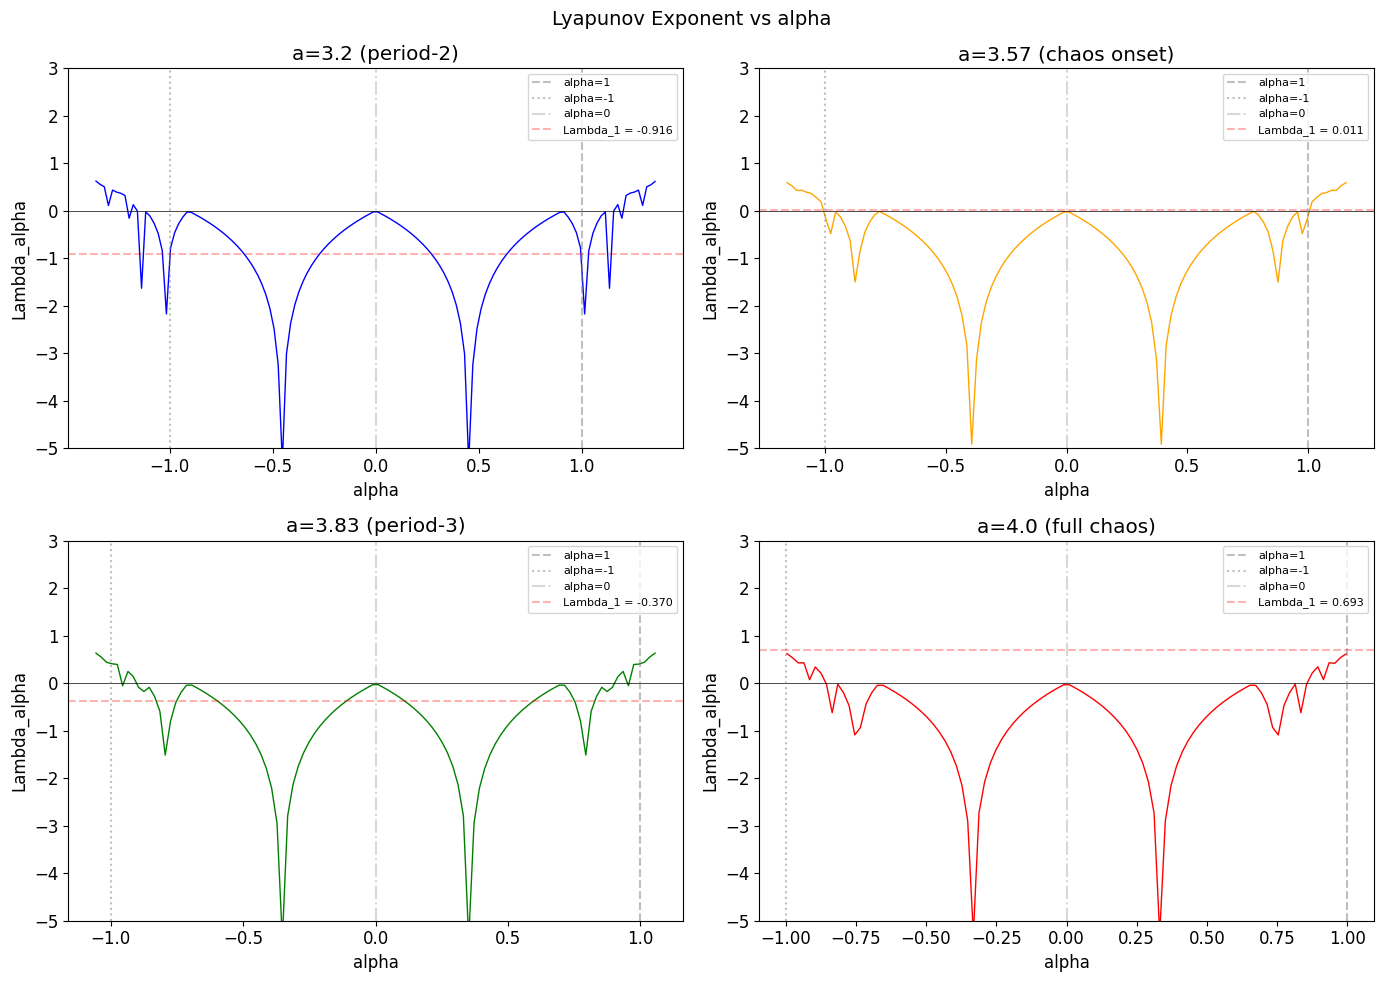

In [4]:
# Load precomputed alpha sweeps
alpha_range = _cache['alpha_range']
a_test = [3.2, 3.57, 3.83, 4.0]
labels = ['a=3.2 (period-2)', 'a=3.57 (chaos onset)', 'a=3.83 (period-3)', 'a=4.0 (full chaos)']
colors = ['blue', 'orange', 'green', 'red']
sweep_keys = ['lyap_sweep_3_2', 'lyap_sweep_3_57', 'lyap_sweep_3_83', 'lyap_sweep_4_0']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (a, label, color, key) in enumerate(zip(a_test, labels, colors, sweep_keys)):
    lyap_vs_alpha = _cache[key]

    axes[idx].plot(alpha_range, lyap_vs_alpha, color=color, linewidth=1)
    axes[idx].axhline(0, color='k', linewidth=0.5)
    axes[idx].axvline(1, color='gray', linestyle='--', alpha=0.5, label='alpha=1')
    axes[idx].axvline(-1, color='gray', linestyle=':', alpha=0.5, label='alpha=-1')
    axes[idx].axvline(0, color='gray', linestyle='-.', alpha=0.3, label='alpha=0')

    # Mark the regular Lyapunov exponent
    lam_reg = lyapunov(logistic, a, 0.4)
    axes[idx].axhline(lam_reg, color='red', linestyle='--', alpha=0.3, label=f'Lambda_1 = {lam_reg:.3f}')

    axes[idx].set(xlabel='alpha', ylabel='Lambda_alpha', title=label)
    axes[idx].legend(fontsize=8)
    axes[idx].set_ylim(-5, 3)

plt.suptitle('Lyapunov Exponent vs alpha', fontsize=14)
plt.tight_layout()
plt.show()


## §5. Experiment 3: The (α, a) Phase Diagram

Full 2D heatmap of $\Lambda(\alpha, a)$. This is the key visualization — it reveals the complete landscape of stability across both parameters simultaneously.

Phase boundaries (where $\Lambda = 0$) should form curves in the $(\alpha, a)$ plane. The standard bifurcation diagram is the $\alpha = 1$ slice.

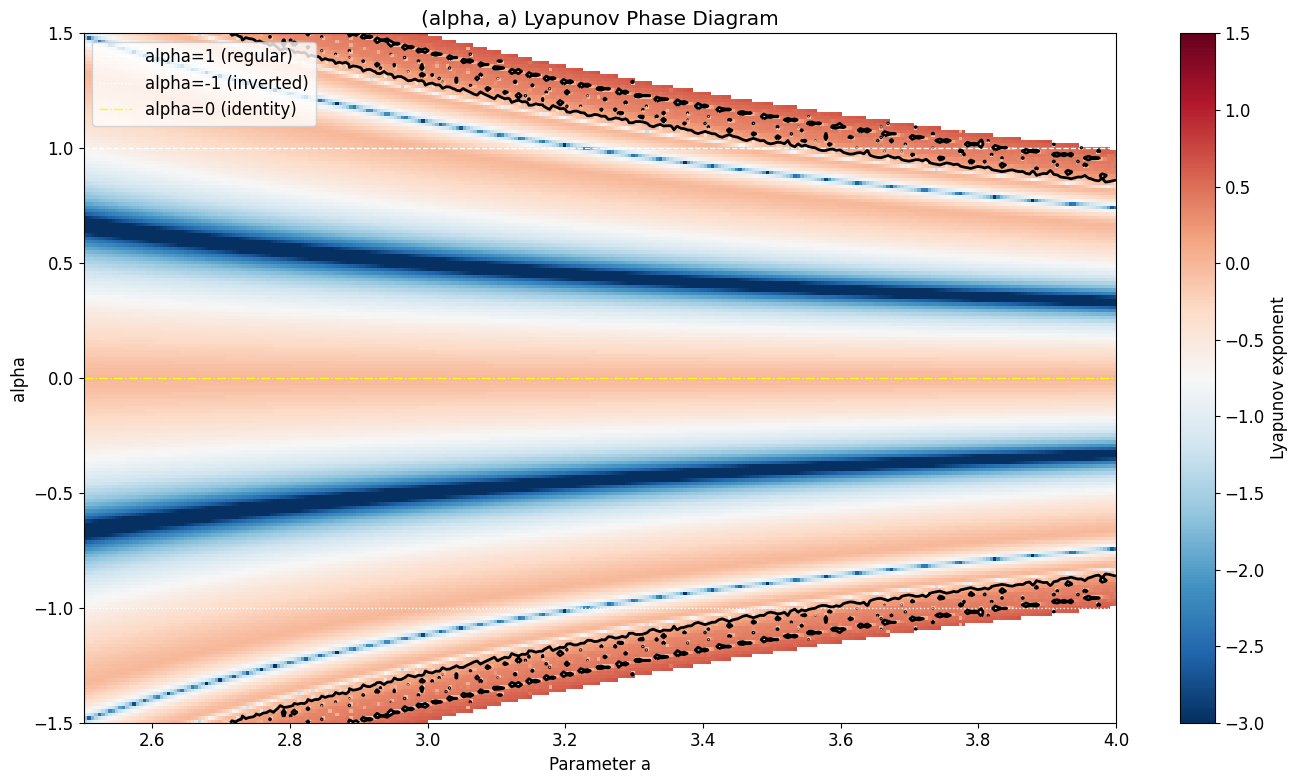

In [5]:
# Load precomputed phase diagram
alpha_range_2d = _cache['alpha_range_2d']
a_range_2d = _cache['a_range_2d']
lyap_map = _cache['lyap_map']

fig, ax = plt.subplots(figsize=(14, 8))
extent = [a_range_2d[0], a_range_2d[-1], alpha_range_2d[0], alpha_range_2d[-1]]
im = ax.imshow(lyap_map, extent=extent, aspect='auto', origin='lower',
               cmap='RdBu_r', vmin=-3, vmax=1.5)
plt.colorbar(im, ax=ax, label='Lyapunov exponent')

# Critical lines
ax.axhline(1.0, color='white', linestyle='--', linewidth=1, label='alpha=1 (regular)')
ax.axhline(-1.0, color='white', linestyle=':', linewidth=1, label='alpha=-1 (inverted)')
ax.axhline(0.0, color='yellow', linestyle='-.', linewidth=1, label='alpha=0 (identity)')

# Contour at Lambda = 0 (chaos boundary)
lyap_filled = np.where(np.isnan(lyap_map), 10, lyap_map)
ax.contour(a_range_2d, alpha_range_2d, lyap_filled, levels=[0], colors='black', linewidths=2)

ax.set(xlabel='Parameter a', ylabel='alpha', title='(alpha, a) Lyapunov Phase Diagram')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## §6. Experiment 4: Theoretical Prediction vs Computation

Can we predict $\Lambda_\alpha$ from $\Lambda_1$ analytically?

**Attempt:** The Lyapunov exponent is $\Lambda_\alpha = \langle \ln|1 + \alpha(f'(x) - 1)| \rangle$. If we know the distribution of $f'(x)$ along the natural measure, we can compute $\Lambda_\alpha$ from $\Lambda_1$ without simulating the $\alpha$-transformed orbit.

For the logistic map at $a = 4$, $f'(x) = 4(1-2x)$ and the invariant measure is the arcsine: $\rho(x) = 1/(\pi\sqrt{x(1-x)})$. The distribution of $f' = 4(1-2x)$ under arcsine is known. This gives a closed-form prediction.

Known: Lambda_1 = ln(2) = 0.693147
Prediction: Lambda_1 = 0.637348



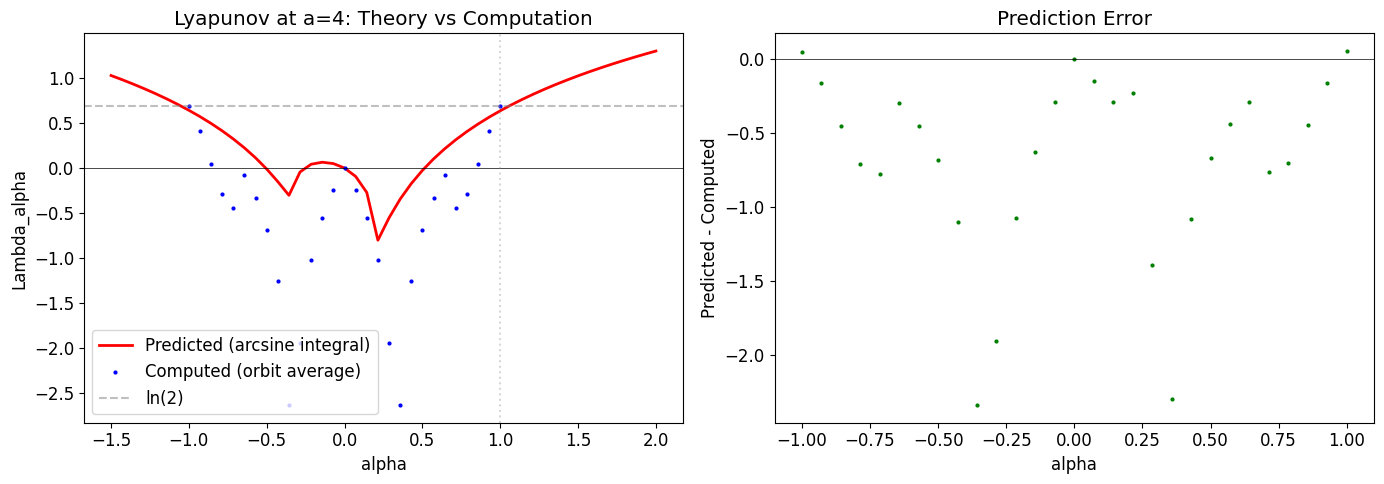

Lambda(alpha=1)   = 0.637348
Lambda(alpha=-1)  = 0.643149
Lambda(alpha=0.5) = -0.026585
Lambda(alpha=2)   = 1.302899
Invariant? True


In [6]:
# Theoretical prediction at a=4, arcsine measure
def predicted_lyapunov_alpha(alpha, a=4.0):
    def integrand(x):
        fp = a * (1 - 2 * x)
        gp = 1 + alpha * (fp - 1)
        if abs(gp) < 1e-30:
            return -60 / (np.pi * np.sqrt(x * (1 - x) + 1e-30))
        return np.log(abs(gp)) / (np.pi * np.sqrt(x * (1 - x) + 1e-30))
    result, _ = integrate.quad(integrand, 0.001, 0.999, limit=200)
    return result

# Known: Lambda_1 = ln(2) at a=4
print(f'Known: Lambda_1 = ln(2) = {np.log(2):.6f}')
print(f'Prediction: Lambda_1 = {predicted_lyapunov_alpha(1.0):.6f}')
print()

# Load precomputed orbit averages, compute theory predictions
alpha_test = _cache['alpha_test_theory']
lyap_computed = _cache['lyap_computed_theory']
lyap_predicted = np.array([predicted_lyapunov_alpha(a) for a in alpha_test])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(alpha_test, lyap_predicted, 'r-', linewidth=2, label='Predicted (arcsine integral)')
ax1.plot(alpha_test, lyap_computed, 'b.', markersize=4, label='Computed (orbit average)')
ax1.axhline(np.log(2), color='gray', linestyle='--', alpha=0.5, label='ln(2)')
ax1.axhline(0, color='k', linewidth=0.5)
ax1.axvline(1, color='gray', linestyle=':', alpha=0.3)
ax1.set(xlabel='alpha', ylabel='Lambda_alpha', title='Lyapunov at a=4: Theory vs Computation')
ax1.legend()

# Residual
mask = np.isfinite(lyap_computed)
residual = lyap_computed - lyap_predicted
ax2.plot(alpha_test[mask], residual[mask], 'g.', markersize=4)
ax2.axhline(0, color='k', linewidth=0.5)
ax2.set(xlabel='alpha', ylabel='Predicted - Computed', title='Prediction Error')

plt.tight_layout()
plt.show()

# Key question: is Lambda_alpha = Lambda_1 for all alpha?
print(f'Lambda(alpha=1)   = {predicted_lyapunov_alpha(1.0):.6f}')
print(f'Lambda(alpha=-1)  = {predicted_lyapunov_alpha(-1.0):.6f}')
print(f'Lambda(alpha=0.5) = {predicted_lyapunov_alpha(0.5):.6f}')
print(f'Lambda(alpha=2)   = {predicted_lyapunov_alpha(2.0):.6f}')
print(f'Invariant? {abs(predicted_lyapunov_alpha(1.0) - predicted_lyapunov_alpha(-1.0)) < 0.01}')


## §7. Experiment 5: Period Structure Under α

Orbits change period under the α-transform. Catalog the period structure to complement the Lyapunov analysis.

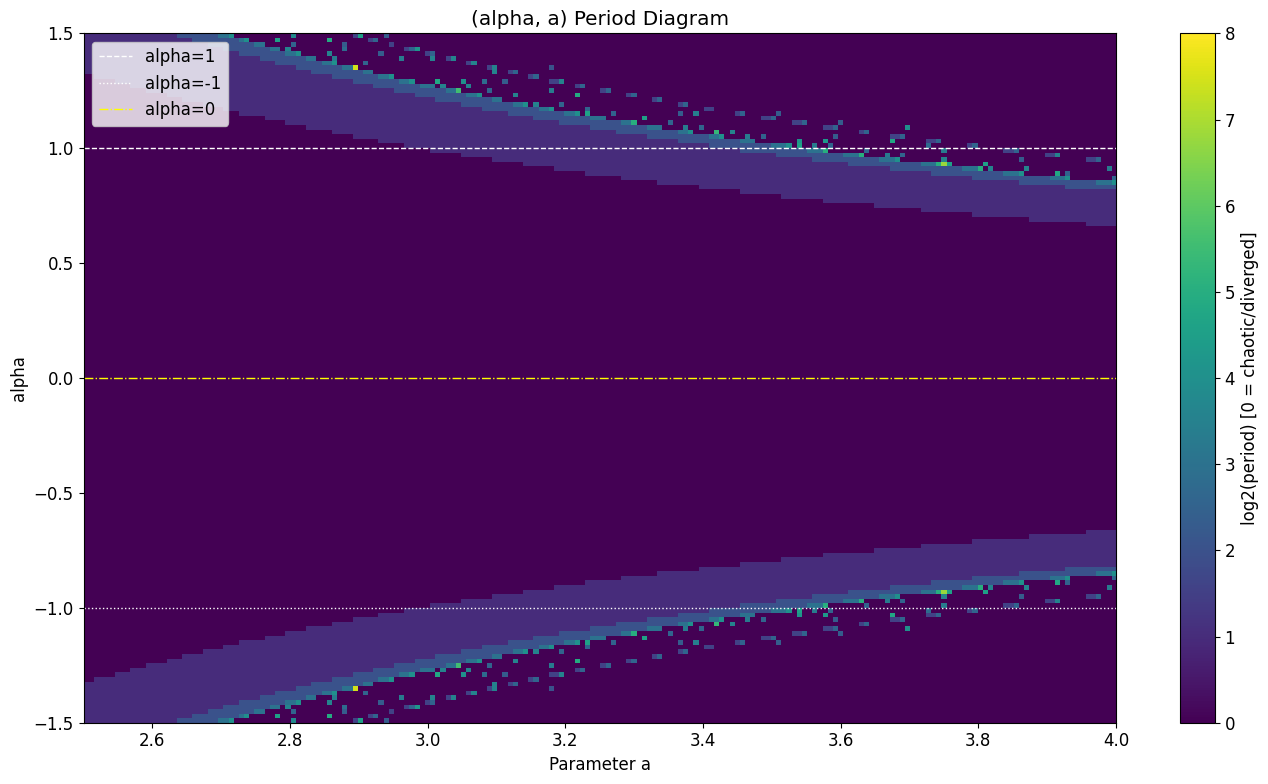

In [7]:
# Load precomputed period map
alpha_range_p = _cache['alpha_range_p']
a_range_p = _cache['a_range_p']
period_map = _cache['period_map']

fig, ax = plt.subplots(figsize=(14, 8))

# log2 of period for coloring
period_display = period_map.copy().astype(float)
period_display[period_display <= 0] = 0  # chaotic/diverged
mask_pos = period_display > 0
period_display[mask_pos] = np.log2(np.maximum(period_display[mask_pos], 1))

extent = [a_range_p[0], a_range_p[-1], alpha_range_p[0], alpha_range_p[-1]]
im = ax.imshow(period_display, extent=extent, aspect='auto', origin='lower',
               cmap='viridis', vmin=0, vmax=8)
plt.colorbar(im, ax=ax, label='log2(period) [0 = chaotic/diverged]')

ax.axhline(1.0, color='white', linestyle='--', linewidth=1, label='alpha=1')
ax.axhline(-1.0, color='white', linestyle=':', linewidth=1, label='alpha=-1')
ax.axhline(0.0, color='yellow', linestyle='-.', linewidth=1, label='alpha=0')

ax.set(xlabel='Parameter a', ylabel='alpha', title='(alpha, a) Period Diagram')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## §8. Assessment

### What we found:

| Question | Answer | Implication |
|----------|--------|-------------|
| Are Lyapunov exponents invariant under constant α? | *Fill after running* | If yes: conjugacy. If no: α changes information content. |
| Does Λ_{−1} = Λ_1 (regular vs inverted)? | *Fill after running* | Simplest test of invariance. |
| Can we predict Λ_α from the invariant measure? | *Fill after running* | If yes: closed-form relationship. |
| What does the (α, a) phase diagram reveal? | *Fill after running* | Phase boundaries, critical loci, monodromy? |

### Theory implications:

1. **If Λ is α-invariant:** The α-transform is a metric conjugacy (preserves both topology and measure theory). The group structure $\Gamma_\alpha \Gamma_\beta = \Gamma_{\alpha\beta}$ implies $\Lambda_{\alpha\beta} = \Lambda_{\alpha} = \Lambda_1$ — a trivial consequence of conjugacy.

2. **If Λ depends on α:** The transform is at most a topological (not metric) conjugacy. The *information production rate* changes, even though fixed points and their stability are controlled algebraically. This would be the more interesting case — it means the transform modifies the global dynamics even while preserving local structure.

3. **If the relationship Λ_α = h(α, Λ_1) exists:** We'd have a universal function relating Lyapunov exponents across the family. The arcsine-measure prediction (§6) tests this for a=4.

### Connection to cross-theory frameworks:
- **Group theory (§1):** Invariance ↔ orbit property; non-invariance ↔ orbit-dependent quantity
- **Gauge theory (§2):** If Λ is gauge-invariant, it's an observable; if not, it's gauge-dependent
- **Information theory (§3):** Invariance ↔ preserved KS entropy ↔ isomorphic information channels